# UN Linear Regression

For this exercise, you've been provided with a csv file, gdp_le.csv, which contains the gdp per capita and life expectancy values that you were working with on the UN data exercise.t.

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import seaborn as sns
import matplotlib.ticker as ticker


In [3]:
gdp_le = pd.read_csv("../data/gdp_le.csv")
gdp_le.head()

,Country,Year,GDP_Per_Capita,Continent,Life_Expectancy
0,Afghanistan,2021,1517.016266,Asia,61.982
1,Afghanistan,2020,1968.341002,Asia,62.575
2,Afghanistan,2019,2079.921861,Asia,63.565
3,Afghanistan,2018,2060.698973,Asia,63.081
4,Afghanistan,2017,2096.093111,Asia,63.016


#### 1. Start by fitting a linear regression model with target being life expectancy and predictor variable year.


In [5]:
linreg_le_yr = smf.ols("Life_Expectancy ~ Year", data=gdp_le).fit()

In [6]:
linreg_le_yr.params

Intercept   -468.138140
Year           0.267722
dtype: float64

##### Substituting these estimates into the model, we get

Mean(Life Expectancy) = -468.138140 + 0.267722(Year)

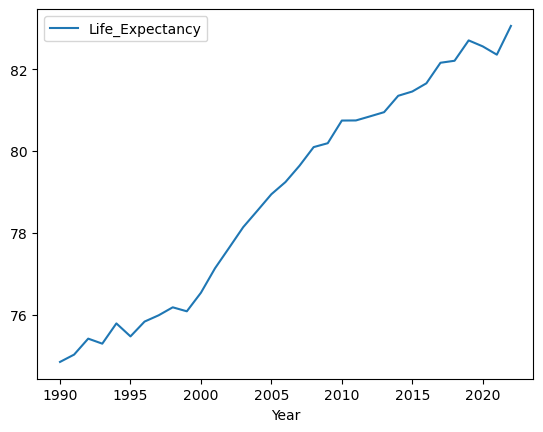

In [8]:
gdp_le[gdp_le["Country"] == 'Ireland'].plot(kind="line", x="Year", y="Life_Expectancy");

#### 1a. What coefficients do you get? Interpret the meaning of these coefficents.

In [10]:
linreg_le_yr.params

Intercept   -468.138140
Year           0.267722
dtype: float64

##### The intercept, -468.14, is where the Life_Expectancy variable intercepts the Y axis when the year is 0. BUT the year is never 0 in this dataset...
##### This is telling us... The intercept term seems odd. 
##### This is telling us that the estimate for avg life expectancy starts at negative 468 years. Why did we get this strange number? Don't want to extrapolate much beyond the range we have. Definitely not back to year 0, which is way outside, 2000 years outside, of hte range of our dataset.
##### The coefficient for year, 0.267722, is the slope. It is the number hta twe myltiply by year to get out estimate. It's a positive number so it's a per unit increase. Per Year. Per year increase in avg life expectancy.


#### 1b. Using just the year makes the intercept term difficult to interpret. Create a new model, but this time use years since 1990 as your predictor variable. Hint: You can the patsy identity function to modify your predictors in your model formula. Inspect the new coefficients and interpret the meaning of them. Are they statistically significant?

In [13]:
year_1990_le = smf.ols("Life_Expectancy ~ I(Year-1990)", data=gdp_le).fit()
year_1990_le.params

Intercept         64.628889
I(Year - 1990)     0.267722
dtype: float64

##### Intercept is 64.628889 and our 0 is 1990 so it is the estimated life expectancy for 1990.
##### the slope is the same, as we would expect. 

In [24]:
year_1990_le.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Life_Expectancy   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     424.0
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           8.13e-91
Time:                        15:25:30   Log-Likelihood:                -19950.
No. Observations:                5504   AIC:                         3.990e+04
Df Residuals:                    5502   BIC:                         3.992e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         64.6289      0.245    263.308      0.000      64.148      65.110
I(Year - 1990)     0.2677      0.013     20.591      0.000       0.242       0.293
==============================================================================
Omnibus:                      387.409   Durbin-Watson:                   0.058
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              469.138
Skew:                          -0.709   Prob(JB):                    1.34e-102
Kurtosis:                       2.820   Cond. No.                         37.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
year_1990 = smf.ols("Life_Expectancy ~ Year + I(Year-1990)", data=gdp_le).fit()
year_1990.params

Intercept        -0.000102
Year              0.032477
I(Year - 1990)    0.235245
dtype: float64

In [28]:
year_1990.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Life_Expectancy   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     424.0
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           8.13e-91
Time:                        15:26:03   Log-Likelihood:                -19950.
No. Observations:                5504   AIC:                         3.990e+04
Df Residuals:                    5502   BIC:                         3.992e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.0001   6.64e-06    -15.342      0.000      -0.000   -8.89e-05
Year               0.0325      0.000    263.314      0.000       0.032       0.033
I(Year - 1990)     0.2352      0.013     17.945      0.000       0.210       0.261
==============================================================================
Omnibus:                      387.409   Durbin-Watson:                   0.058
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              469.138
Skew:                          -0.709   Prob(JB):                    1.34e-102
Kurtosis:                       2.820   Cond. No.                     1.23e+19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.47e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

##### WHAT DOES THIS MEAN

#### Are they statistically significant?
##### Yes, based on the P values being less than 0.05 and the span of the inner quartile range being both greater than 0, I can posit that there is a non null effect. We can reject the null hypothesis and accept that the year is statistically significant as it relates to life expectancy

In [37]:
#plt.scatter(gdp_le('Year'), gdp_le('Life_Expectancy'))

##### Everything is so spread out so it is hard to make an informed guess/estimate. 

#### 1c. Compare the actual mean life expectancy per year to the model's estimate. How well does it do?

In [160]:
gdp_le['Life_Expectancy'].mean()

69.01011528644356

In [173]:
mean_le = gdp_le.groupby('Year')['Life_Expectancy'].mean().reset_index()
mean_le['mean_estimate'] = linreg_le_yr.predict(mean_le)
mean_le.head(2)

,Year,Life_Expectancy,mean_estimate
0,1990,64.745253,64.628889
1,1991,65.021276,64.896612


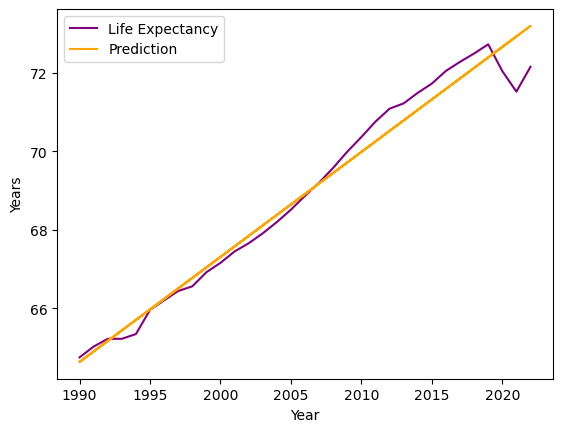

In [181]:
mean_le.plot(kind='line', x='Year', y='Life_Expectancy', color='purple')
plt.plot(gdp_le['Year'], linreg_le_yr.fittedvalues, color='orange')
plt.ylabel('Years')
plt.legend(['Life Expectancy', 'Prediction']);

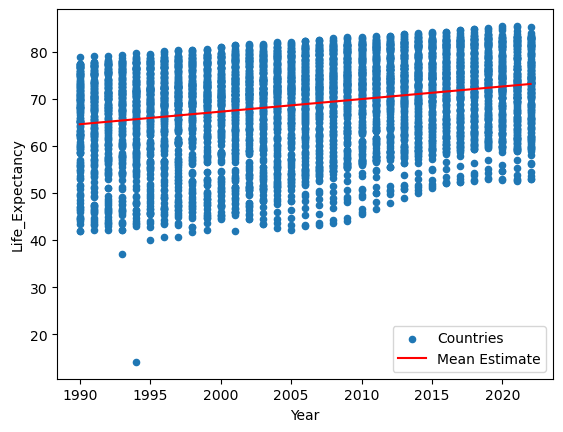

In [189]:
fig, ax = plt.subplots()
gdp_le.plot(kind='scatter', x='Year', y='Life_Expectancy', ax=ax)
mean_le.plot(x='Year', y='mean_estimate', ax=ax, color='red')
plt.legend(['Countries', 'Mean Estimate']);

As far as the estimated average it's pretty good at predicting the average, but not predicting any one country's life expectancy.

#### 1d. Plot the actual values against your model's estimates for the mean life expectancy.

In [58]:
estimate = pd. DataFrame(
    {
        'Year': np.linspace(start=gdp_le['Year'].min(), stop=gdp_le['Year'].max())
    }
             )
estimate['mean_estimate'] = year_1990_le.predict(estimate)
estimate['Year-1990'] = estimate['Year']-1990
estimate.head(2)

,Year,mean_estimate,Year-1990
0,1990.000000,64.628889,0.000000
1,1990.653061,64.803728,0.653061


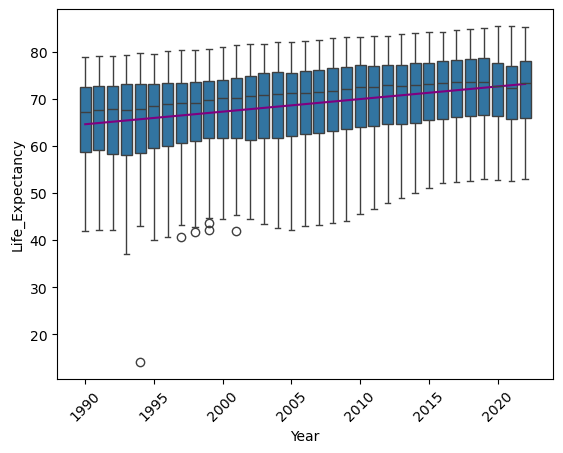

In [162]:
fig, ax = plt.subplots()
sns.boxplot(data=gdp_le, x='Year', y='Life_Expectancy', ax=ax)
sns.lineplot(data=estimate, x='Year-1990', y='mean_estimate', color='purple', ax=ax)
plt.xticks(rotation=45)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5));

#### 1e. Inspect the R-squared value for the model. does it make sense, given the plot?

The data is slightly left skewed. Estimated average is a little below the median. And that is in line with the data being left skewed. The R-squared is in line with what is seen in these plots. There is still a lot more variability that hasn't been explained with just. You can have a perfect model with a low r-squared value, becuase it's looking at how much variability in life expectancy is explained by the model. We're pretty good at getting average life expectancy correct from the model but there is still a lot of variability in life expectancy around each year. 

In [221]:
linreg_le_yr.rsquared

0.07154748843194658

In [223]:
variance_le = gdp_le['Life_Expectancy'].var()

In [229]:
print(f'Variance in life expectancy overall is {variance_le}.')

Variance in life expectancy overall is 88.74671724809252.


In [231]:
linreg_le_yr.resid.var()

82.39711252241109

variance in the residuals is 82.4 - the size from each point to the line. These residuals have reduce the amount of variance but not by much, only about 7%.

In [152]:
year_1990_le.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Life_Expectancy   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     424.0
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           8.13e-91
Time:                        17:25:32   Log-Likelihood:                -19950.
No. Observations:                5504   AIC:                         3.990e+04
Df Residuals:                    5502   BIC:                         3.992e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         64.6289      0.245    263.308      0.000      64.148      65.110
I(Year - 1990)     0.2677      0.013     20.591      0.000       0.242       0.293
==============================================================================
Omnibus:                      387.409   Durbin-Watson:                   0.058
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              469.138
Skew:                          -0.709   Prob(JB):                    1.34e-102
Kurtosis:                       2.820   Cond. No.                         37.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 2. Filter the full dataset down to just the year 2021. Fit a linear regression model with target being life expectancy and predictor variable gdp per capita.

In [237]:
gdp_le_2021 = gdp_le[gdp_le['Year'] == 2021]

In [241]:
linreg_le_gdp = smf.ols('Life_Expectancy ~ GDP_Per_Capita', data=gdp_le_2021).fit()

#### 2a. What coefficients do you get? Interpret the meaning of those coefficients.

In [248]:
linreg_le_gdp.params

Intercept         65.949870
GDP_Per_Capita     0.000257
dtype: float64

The estimated avgerage life expectancy for a country with 0 gdp per capita is 65.949870. The estimated average life expectancy increases by 0.000257 for every dollar increase in gdp per capita. 

#### 2b. Refit your model, but this time use thousands of dollars of gdp per capita as your predictor. How does this change your coefficients?

In [264]:
linreg_le_gdp = smf.ols('Life_Expectancy ~ I(GDP_Per_Capita/1000)', data=gdp_le_2021).fit()
linreg_le_gdp.params

Intercept                   65.949870
I(GDP_Per_Capita / 1000)     0.256892
dtype: float64

#### 2c. Are the coefficients statistically significant?

#### 2d. What does your model estimate for the mean life expectancy for a country whose gdp per capita is 50,000 dollars? What about one whose gdp per capita is $100,000? 



#### 2e. Plot the actual values compared to your model's estimates for mean life expectancy. How would you assess the model's fit?

#### 3. Now, fit a model for life expectancy based on the log of gdp per capita.


#### 3a. Inspect the coefficients for this model. Are they statistically significant? 

#### 3b. Interpret these coefficients. What does the model estimate for the average life expectancy for countries with a gdp per capita of \$$50,000 ? What about for those with a gdp per capita of \$100,000? 

#### 3c. Plot the actual values compared to your models' estimates for the mean life expectancy. How does this compare to the non-logged model?

#### 4 Finally, return to the full dataset. a. First, fit a linear regression model for life expectancy based on the log of gdp per capita. 

#### 4b. Then, add the year variable to your model. How can you interpret the coefficient associated with year? What limitations or weaknesses might this model have?